# CausalMan: Generating Synthetic Causal Data

This notebook demonstrates how to use the `CausalMan` class to generate synthetic data with a known causal structure. The workflow is explained step by step, with a focus on clarity and reproducibility.

---


## 1. Setup and Imports

First, we import the necessary libraries and the `CausalMan` class. This class is the main entry point for generating synthetic causal data. Make sure your working directory is set correctly so that imports from the `src` folder work.

In [1]:
import os
from datetime import datetime
from pathlib import Path
import sys

# Put the repository root before this notebook directory so causalman.py
# cannot shadow the causalman package when the notebook runs in-place.
PROJECT_ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents)
                     if (path / "pyproject.toml").is_file()
                     and (path / "causalman" / "__init__.py").is_file()), None)
if PROJECT_ROOT is not None:
    project_root = str(PROJECT_ROOT)
    if project_root in sys.path:
        sys.path.remove(project_root)
    sys.path.insert(0, project_root)

from causalman import CausalMan


## 2. Configuration Setup

Instead of loading from a config file, we'll define our configuration directly. This makes it easier to understand what each parameter does and how it affects the simulation.

In [2]:
# Configuration variables for demonstration
random_state_seed = 123  # Random seed for reproducibility
n_samples = 10_000  # Number of rows to keep in the generated dataset

debug_mode = False  # Enable debug mode for verbose output
parallelize = True  # Use parallel processing (set True for large simulations)
max_workers = 5  # Number of parallel workers (if parallelize is True)
choice = "causalman_micro"  # micro | small | medium | large
batch_multiplier = 1  # Increase this if the simulator produces fewer than n_samples rows
save_path = "output/"  # Output directory for results


## 3. Output Directory Setup

We'll create a timestamped output directory for this run, making it easy to keep results from different experiments organized.

In [3]:
# Create a timestamped output directory for this run
now = datetime.now().strftime("%Y_%m_%d_%H%M%S")
output_dir = os.path.join(save_path, f"{choice}_{now}")
os.makedirs(output_dir, exist_ok=True)
print(f"Results will be saved to: {output_dir}")

Results will be saved to: output/causalman_micro_2026_08_06_134209


## 4. Initialize the CausalMan Simulator

Now we create an instance of the `CausalMan` class using the configuration variables above. This sets up the simulation scenario and prepares everything for data generation.

In [4]:
# Initialize the CausalMan simulator
simulator = CausalMan(
    name=choice,
    seed=random_state_seed,
    parallelize=parallelize,
    max_workers=max_workers,
    debug_mode=debug_mode,
    save_path=output_dir
)
print(f"Initialized CausalMan with scenario: {choice}")

Initialized CausalMan with scenario: causalman_micro


## 5. Generate Synthetic Data

Run the simulator and then deterministically retain exactly `n_samples` rows.
If the simulator output is too small, increase `batch_multiplier`.

In [5]:
# Run the simulation
(
    obs_dataset,
    mag,
    admg,
    fully_observable_dataset,
    dag,
    interventional_table,
) = simulator.sample()

n_generated = len(obs_dataset)
if n_generated < n_samples:
    raise RuntimeError(
        f"The simulator generated {n_generated:,} rows, "
        f"but n_samples={n_samples:,}. "
        "Increase batch_multiplier or reduce n_samples."
    )

obs_dataset = (
    obs_dataset.sample(n=n_samples, random_state=random_state_seed)
    .reset_index(drop=True)
)

print(f"Simulator generated {n_generated:,} rows.")
print(f"Kept {len(obs_dataset):,} rows using seed {random_state_seed}.")
print(
    f"Causal graph has {len(dag.nodes())} nodes "
    f"and {len(dag.edges())} edges."
)


Starting simulation for production line 0 out of 1
Finished sampling
Simulator generated 14,813 rows.
Kept 10,000 rows using seed 123.
Causal graph has 157 nodes and 251 edges.


## 6. Save Generated Data

Save the requested observational sample and the simulator's interventional table.

In [6]:
# Save the requested observational sample and simulator metadata
batch_data_path = os.path.join(
    output_dir,
    f"{choice}_observational_n{n_samples}_RS{random_state_seed}.csv",
)
interventional_table_path = os.path.join(
    output_dir,
    f"{choice}_interventional_table.csv",
)

obs_dataset.to_csv(batch_data_path, index=False)
interventional_table.to_csv(interventional_table_path, index=False)

print(f"Saved observational data to: {batch_data_path}")
print(f"Saved interventional table to: {interventional_table_path}")


Saved observational data to: output/causalman_micro_2026_08_06_134209\causalman_micro_observational_n10000_RS123.csv
Saved interventional table to: output/causalman_micro_2026_08_06_134209\causalman_micro_interventional_table.csv


## 7. Analyze the Causal Graph

The full DAG, projected ADMG, and MAG are returned directly by
`CausalMan.sample()`.


In [7]:
# Print basic information about the causal graph
print(f"Causal graph nodes: {list(dag.nodes())[:10]} ...")
print(f"Number of nodes: {len(dag.nodes())}")
print(f"Number of edges: {len(dag.edges())}")


Causal graph nodes: ['MV1_T1_MV_Type_ID_num', 'MV1_T1_MV_Supplier_ID_num', 'MV1_LmvPF', 'MV1_DmvMax', 'MV1_DmvMin', 'MV1_Emv', 'MV1_AleakMV_raw', 'MV1_AleakMV', 'MV2_T2_MV_Type_ID_num', 'MV2_T2_MV_Supplier_ID_num'] ...
Number of nodes: 157
Number of edges: 251


## 8. Inspect the Generated Data

The returned `obs_dataset` can be used directly; no additional masking or
column selection is required.


In [8]:
print("Observational data sample:")
display(obs_dataset.head())


Observational data sample:


,MV1_T1_MV_Supplier_ID_num,MV2_T2_MV_Supplier_ID_num,HU_HU_Block_Supplier_ID_num,PF_M1_T1_s0,PF_M1_T1_Force,PF_M1_T1_Force_MpGood,PF_M1_T1_sgrad,PF_M1_T1_sgrad_MpGood,PF_M1_T1_Fmax,PF_M1_T1_Fmax_MpGood,...,PF_M1_T2_Force,PF_M1_T2_Force_MpGood,PF_M1_T2_sgrad,PF_M1_T2_sgrad_MpGood,PF_M1_T2_Fmax,PF_M1_T2_Fmax_MpGood,PF_M1_T2_smax,PF_M1_T2_smax_MpGood,Sec_C2_Machine1_ProcessResult,batch_ID_num
0,22.0,22.0,11.0,10.000769,13962.184732,1.0,17.315209,1.0,20470.916988,1.0,...,19258.682784,0.0,18.384694,1.0,25762.230285,0.0,19.676602,1.0,0.0,0.0
1,22.0,22.0,12.0,10.199250,15632.644581,1.0,17.667379,1.0,22484.949054,1.0,...,14401.784361,1.0,17.442573,1.0,21401.608863,1.0,18.764371,1.0,1.0,25.0
2,22.0,22.0,12.0,10.210243,18142.636270,1.0,18.145463,1.0,25347.831615,0.0,...,16215.586548,1.0,17.749433,1.0,23221.537933,1.0,19.074601,1.0,0.0,1.0
3,22.0,22.0,11.0,10.199724,15245.380065,1.0,17.623544,1.0,22337.663574,1.0,...,14299.741824,1.0,17.423655,1.0,21423.735909,1.0,18.767115,1.0,1.0,24.0
4,22.0,21.0,11.0,10.215432,18240.941456,1.0,18.172516,1.0,25099.566184,0.0,...,11996.098621,1.0,16.959528,1.0,19002.686912,1.0,18.278906,1.0,0.0,20.0


## 9. Visualize a Key Variable: `PF_M1_T1_Force`


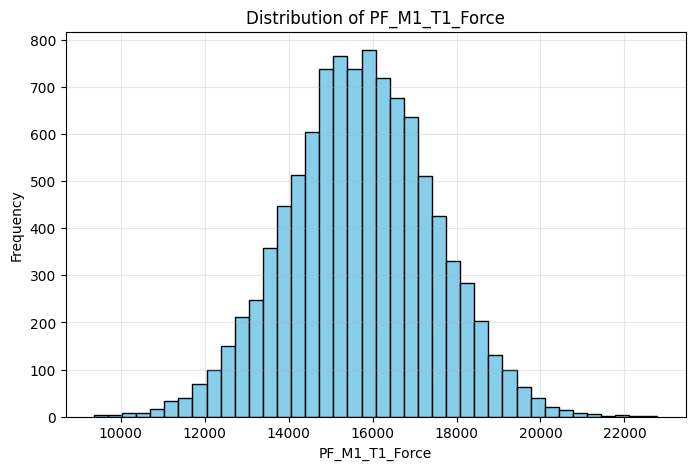

In [9]:
import matplotlib.pyplot as plt

var_name = "PF_M1_T1_Force"
if var_name in obs_dataset.columns:
    plt.figure(figsize=(8, 5))
    plt.hist(obs_dataset[var_name], bins=40, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {var_name}")
    plt.xlabel(var_name)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print(f"Variable '{var_name}' not found in the generated data.")